# 1D ODE Boundary Value Problem with a user forcing Term
### User Forcing term -> x cube
### Boundary Conditions: y(0) = 0, y(L) = 0
### Domain: 0 < x < L

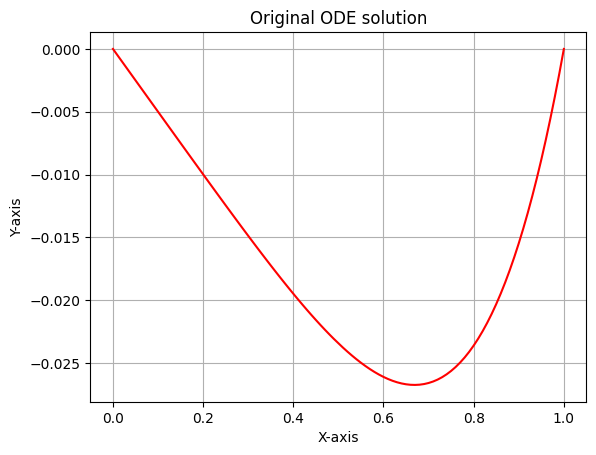

In [10]:
import matplotlib.pyplot as plt
import numpy as np

x = np.round(np.linspace(0, 1, 100), 2)
y = ((x ** 5) / 20) - (1/20)*x

plt.plot(x, y, color='red')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Original ODE solution')
plt.grid()
plt.savefig('ODE_analytical_solution.png', dpi=300, bbox_inches='tight')
plt.show()

In [3]:
import tensorflow as tf
from tensorflow.keras import layers, models
import time

model = tf.keras.Sequential([
    layers.Input(shape=(1,)),
    layers.Lambda(lambda x: x * 2.0 - 1.0),
    layers.Dense(32, activation='tanh'),
    layers.Dense(32, activation='tanh'),
    layers.Dense(1)
])

optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
model.summary()


2026-03-02 02:05:01.459256: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-03-02 02:05:01.680451: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1772397301.758434    6182 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1772397301.792313    6182 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1772397301.950181    6182 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking 

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 1)              │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │            64 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,153 (4.50 KB)

 Trainable params: 1,153 (4.50 KB)

 Non-trainable params: 0 (0.00 B)

In [90]:
def ode_loss_func(model, x):
    with tf.GradientTape(persistent=True) as tape2:
        tape2.watch(x)
        with tf.GradientTape(persistent=True) as tape1:
            tape1.watch(x)
            y = model(x)
        dy_dx = tape1.gradient(y, x)
    d2y_dx2 = tape2.gradient(dy_dx, x)
    return tf.reduce_mean((d2y_dx2 - x**3)**2)

def ode_bc_loss_func(model):
    x0 = tf.zeros((1, 1))
    xL = tf.ones((1, 1))

    y0 = model(x0)
    yL = model(xL)
    return tf.reduce_mean(y0**2) + tf.reduce_mean(yL**2)

lmb_ode = 5
lmb_bc = 7

In [91]:
x = tf.convert_to_tensor(np.round(np.linspace(0, 1, 100), 2), dtype=tf.float32)
epochs = 512
for epoch in range(epochs):
    start = time.time()
    epoch_loss = 0.0
    with tf.GradientTape() as tape:
        ode_loss = ode_loss_func(model, x)
        bc_loss = ode_bc_loss_func(model)

        total_loss = lmb_ode * ode_loss + lmb_bc * bc_loss
    gradients = tape.gradient(total_loss, model.trainable_variables)
    optimizer.apply_gradients(zip(gradients, model.trainable_variables))
    cost = time.time() - start

    if(epoch % 100 == 0):
        print(f"Cost: {cost}, Epoch: {epoch + 1}/{epochs}, ode_loss: {ode_loss}, bc_loss: {bc_loss}, total_loss: {total_loss}")
print('Model_saved at: ode_model.keras')
model.save('ode_model.keras')

Cost: 0.049364566802978516, Epoch: 1/512, ode_loss: 0.00982589740306139, bc_loss: 1.7380991721438477e-06, total_loss: 0.04914165288209915
Cost: 0.032289981842041016, Epoch: 101/512, ode_loss: 0.004463840276002884, bc_loss: 1.431757027603453e-06, total_loss: 0.02232922427356243
Cost: 0.03203916549682617, Epoch: 201/512, ode_loss: 0.002557356609031558, bc_loss: 9.66171228355961e-07, total_loss: 0.012793546542525291
Cost: 0.03187441825866699, Epoch: 301/512, ode_loss: 0.00158705934882164, bc_loss: 5.20594426234311e-07, total_loss: 0.00793894100934267
Cost: 0.032212018966674805, Epoch: 401/512, ode_loss: 0.0010595128405839205, bc_loss: 2.5503931055936846e-07, total_loss: 0.005299349315464497
Cost: 0.03165698051452637, Epoch: 501/512, ode_loss: 0.0007834187126718462, bc_loss: 1.0510267145491525e-07, total_loss: 0.003917829133570194
Model_saved at: ode_model.keras


In [8]:
inference_model = tf.keras.models.load_model('ode_model.keras', safe_mode=False)

x = np.round(np.linspace(0, 1, 1000), 5)
y = ((x ** 5) / 20) - (1/20)*x
y_pred = inference_model(tf.convert_to_tensor(x, dtype=tf.float32), training=False)

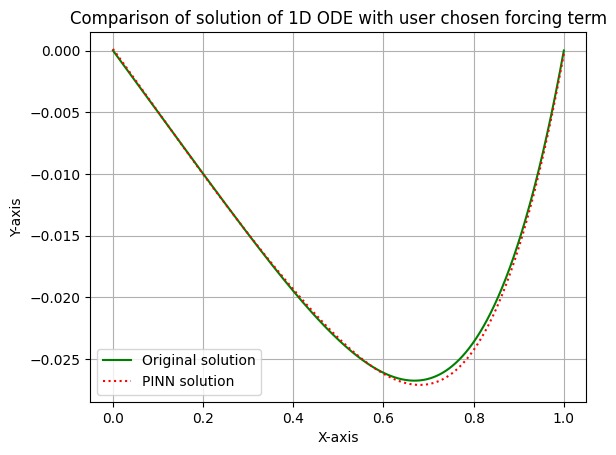

In [9]:
plt.plot(x, y, color='green', label='Original solution')
plt.plot(x, y_pred, color='red', label='PINN solution', ls=':')
plt.xlabel('X-axis')
plt.ylabel('Y-axis')
plt.title('Comparison of solution of 1D ODE with user chosen forcing term')
plt.grid('off')
plt.legend()
plt.savefig('Comparison_of_soltion_of_1D_ODE_PINN_Solution.png', dpi=300, bbox_inches='tight')
plt.show()